Image Dimensions: (452, 678)


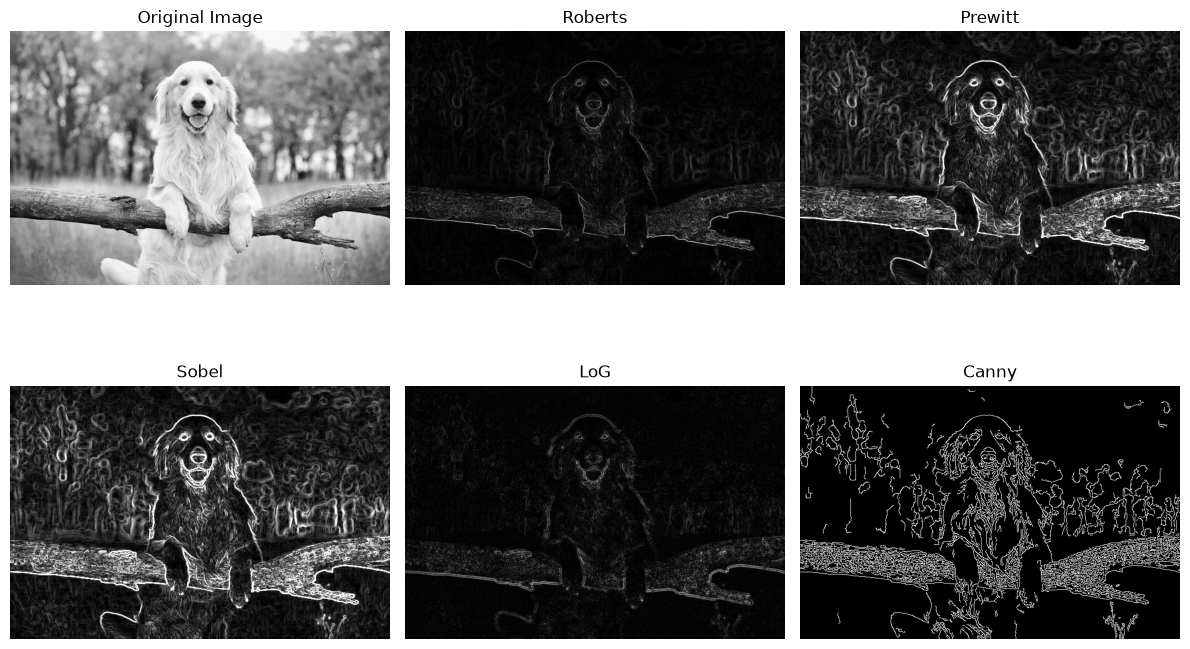

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = "../images/dog_grayscale.png"

img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Error: Image not found!")
    exit()

print("Image Dimensions:", img.shape)


roberts_x = np.array([
    [1, 0],
    [0, -1]
], dtype=np.float32)

roberts_y = np.array([
    [0, 1],
    [-1, 0]
], dtype=np.float32)

gx_roberts = cv2.filter2D(img, cv2.CV_32F, roberts_x)
gy_roberts = cv2.filter2D(img, cv2.CV_32F, roberts_y)

roberts = cv2.magnitude(gx_roberts, gy_roberts)

roberts = cv2.convertScaleAbs(roberts)

cv2.imwrite("roberts.jpg", roberts)


prewitt_x = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

prewitt_y = np.array([
    [-1, -1, -1],
    [0, 0, 0],
    [1, 1, 1]
], dtype=np.float32)

gx_prewitt = cv2.filter2D(img, cv2.CV_32F, prewitt_x)
gy_prewitt = cv2.filter2D(img, cv2.CV_32F, prewitt_y)

prewitt = cv2.magnitude(gx_prewitt, gy_prewitt)

prewitt = cv2.convertScaleAbs(prewitt)

cv2.imwrite("prewitt.jpg", prewitt)


gx_sobel = cv2.Sobel(img, cv2.CV_32F, 1, 0, ksize=3)
gy_sobel = cv2.Sobel(img, cv2.CV_32F, 0, 1, ksize=3)

sobel = cv2.magnitude(gx_sobel, gy_sobel)

sobel = cv2.convertScaleAbs(sobel)

cv2.imwrite("sobel.jpg", sobel)


blurred = cv2.GaussianBlur(img, (5, 5), 0)

log = cv2.Laplacian(blurred, cv2.CV_64F)

log = cv2.convertScaleAbs(log)

cv2.imwrite("log.jpg", log)


low_threshold = 50
high_threshold = 150

canny = cv2.Canny(img, low_threshold, high_threshold)

cv2.imwrite("canny.jpg", canny)

plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(roberts, cmap="gray")
plt.title("Roberts")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(prewitt, cmap="gray")
plt.title("Prewitt")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(sobel, cmap="gray")
plt.title("Sobel")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(log, cmap="gray")
plt.title("LoG")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(canny, cmap="gray")
plt.title("Canny")
plt.axis("off")

plt.tight_layout()
plt.show()

(np.float64(-0.5), np.float64(677.5), np.float64(451.5), np.float64(-0.5))

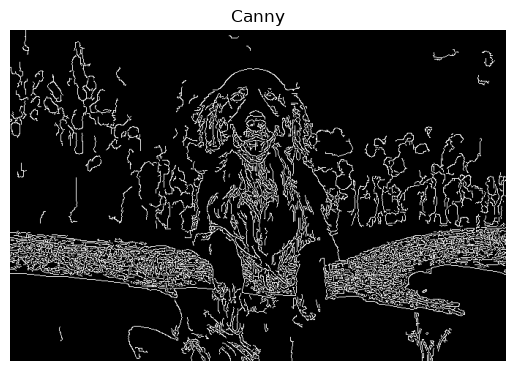

In [3]:
plt.imshow(canny, cmap="gray")
plt.title("Canny")
plt.axis("off")